In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# ======================================================
# 1. Dual-Stream 데이터 로더
#    (Level 데이터와 Pattern 데이터를 동시에 생성)
# ======================================================
def load_dual_stream_data(folder_path, input_dim=3000, mode='train'):
    print(f"\n📂 [{mode.upper()}] 데이터 로딩 및 전처리: {folder_path}")

    if not os.path.exists(folder_path):
        print(f"   🚨 폴더가 존재하지 않습니다.")
        return None, None, None

    X_list = []
    y_or_id_list = []

    # --- 파일 탐색 ---
    if mode == 'train':
        # 정답 파일(_type.csv) 기준
        target_files = glob.glob(os.path.join(folder_path, "*_type.csv"))
    else:
        # 데이터 파일(.csv) 기준 (정답 파일 제외)
        all_csvs = glob.glob(os.path.join(folder_path, "*.csv"))
        target_files = [f for f in all_csvs if "_type.csv" not in f]

    print(f"   -> 대상 파일 {len(target_files)}개 발견. 읽기 시작...")

    for file_path in tqdm(target_files):
        try:
            # 경로 설정
            if mode == 'train':
                type_path = file_path
                data_path = type_path.replace("_type.csv", ".csv")
                if not os.path.exists(data_path): continue

                # 라벨 읽기
                df_type = pd.read_csv(type_path, header=None)
                label = str(df_type.iloc[0, 0])
                y_or_id_list.append(label)
            else:
                data_path = file_path
                # ID 추출
                filename = os.path.basename(data_path)
                barcode_id = os.path.splitext(filename)[0]
                y_or_id_list.append(barcode_id)

            # 데이터 읽기
            df_data = pd.read_csv(data_path, header=None)
            vec = df_data.values.flatten()

            if len(vec) != input_dim: continue
            X_list.append(vec)

        except Exception:
            continue

    # Numpy 변환
    X_raw = np.array(X_list, dtype=np.float32)
    meta_data = np.array(y_or_id_list)

    if len(X_raw) == 0:
        print("   🚨 로드된 데이터가 없습니다.")
        return None, None, None

    print(f"   -> 원본 데이터 로드 완료: {X_raw.shape}")

    # --- [핵심] Dual Stream 생성 ---

    # 1. Stream A: Level Data (Log1p of Raw Counts)
    # 절대적인 발현량 크기를 학습
    if np.max(X_raw) > 20:
        X_level = np.log1p(X_raw)
    else:
        X_level = X_raw # 이미 정규화 된 경우

    # 2. Stream B: Pattern Data (Library Size Norm + Log1p)
    # 세포별 총합을 10,000으로 맞춰서 '상대적 비율'을 학습
    library_sizes = X_raw.sum(axis=1, keepdims=True)
    library_sizes[library_sizes == 0] = 1 # 0 나누기 방지

    X_pattern = (X_raw / library_sizes) * 1e4 # CP10k
    X_pattern = np.log1p(X_pattern)

    print("   -> Dual Stream 생성 완료 (Level + Pattern)")

    return X_level, X_pattern, meta_data

# ======================================================
# 2. Dual-Stream Dataset 클래스
# ======================================================
class DualStreamDataset(Dataset):
    def __init__(self, X_level, X_pattern, y_data=None):
        self.X_level = torch.tensor(X_level, dtype=torch.float32)
        self.X_pattern = torch.tensor(X_pattern, dtype=torch.float32)

        if y_data is None:
            self.y = torch.zeros(len(X_level), dtype=torch.long) # Dummy for test
        else:
            self.y = torch.tensor(y_data, dtype=torch.long)

    def __len__(self):
        return len(self.X_level)

    def __getitem__(self, idx):
        # (Level입력, Pattern입력, 정답) 3가지를 반환
        return self.X_level[idx], self.X_pattern[idx], self.y[idx]

# ======================================================
# 3. Dual-Stream VAE 모델 아키텍처
# ======================================================
class DualStreamVAEClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, latent_dim=64, hidden_dim=512):
        super(DualStreamVAEClassifier, self).__init__()

        # --- Stream A: Level Encoder ---
        self.encoder_level = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.mu_level = nn.Linear(hidden_dim, latent_dim // 2)
        self.logvar_level = nn.Linear(hidden_dim, latent_dim // 2)

        # --- Stream B: Pattern Encoder ---
        self.encoder_pattern = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.mu_pattern = nn.Linear(hidden_dim, latent_dim // 2)
        self.logvar_pattern = nn.Linear(hidden_dim, latent_dim // 2)

        # --- Decoder (Level 데이터 복원 목표) ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

        # --- Classifier (Fusion) ---
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128), # 배치 정규화 추가
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x_level, x_pattern):
        # 1. Level Stream
        h1 = self.encoder_level(x_level)
        mu1 = self.mu_level(h1)
        lv1 = self.logvar_level(h1)
        z1 = self.reparameterize(mu1, lv1) if self.training else mu1

        # 2. Pattern Stream
        h2 = self.encoder_pattern(x_pattern)
        mu2 = self.mu_pattern(h2)
        lv2 = self.logvar_pattern(h2)
        z2 = self.reparameterize(mu2, lv2) if self.training else mu2

        # 3. Fusion (Concatenate)
        z = torch.cat([z1, z2], dim=1) # (Batch, 64)

        # 4. Recon & Classify
        recon_x = self.decoder(z) # Level 데이터를 복원하도록 유도
        logits = self.classifier(z)

        # Loss 계산용 통합 Mu, LogVar
        mu = torch.cat([mu1, mu2], dim=1)
        logvar = torch.cat([lv1, lv2], dim=1)

        return recon_x, logits, mu, logvar

def loss_function(recon_x, x_target, pred_logits, target_labels, mu, logvar, alpha=20.0):
    # 1. Reconstruction Loss (Level 데이터 기준)
    recon_loss = F.mse_loss(recon_x, x_target, reduction='sum')

    # 2. KL Divergence
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # 3. Classification Loss
    cls_loss = F.cross_entropy(pred_logits, target_labels, reduction='sum')

    return recon_loss + kld_loss + (alpha * cls_loss)

# ======================================================
# 4. 메인 실행 (학습 -> 검증 -> 테스트 예측)
# ======================================================

# [설정] 경로를 본인 환경에 맞게 수정하세요!
TRAIN_FOLDER = './Training_Data/'
TEST_FOLDER  = './Test_Data/'

INPUT_DIM = 3000
LATENT_DIM = 64 # (32 Level + 32 Pattern)
BATCH_SIZE = 64
EPOCHS = 30 # 모델이 조금 복잡해졌으므로 Epoch 약간 증가 추천

# --- 1. 데이터 로드 ---
X_lvl_train_all, X_pat_train_all, y_train_labels = load_dual_stream_data(TRAIN_FOLDER, INPUT_DIM, 'train')
X_lvl_test, X_pat_test, test_ids = load_dual_stream_data(TEST_FOLDER, INPUT_DIM, 'test')

if X_lvl_train_all is None:
    exit()

# --- 2. 라벨 인코딩 ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_labels)
NUM_CLASSES = len(le.classes_)
print(f"분류 클래스({NUM_CLASSES}개): {le.classes_}")

# --- 3. 검증셋 분리 (Stratify 적용!) ---
# 희귀 세포가 한쪽에 쏠리는 것을 방지합니다.
try:
    X_lvl_train, X_lvl_val, X_pat_train, X_pat_val, y_train, y_val = train_test_split(
        X_lvl_train_all, X_pat_train_all, y_train_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_train_encoded # ★ 핵심: 비율 유지
    )
except ValueError:
    print("⚠️ [Warning] 일부 클래스의 데이터가 너무 적어 Stratify 실패. 랜덤 분할합니다.")
    X_lvl_train, X_lvl_val, X_pat_train, X_pat_val, y_train, y_val = train_test_split(
        X_lvl_train_all, X_pat_train_all, y_train_encoded,
        test_size=0.2, random_state=42
    )

# --- 4. DataLoader ---
train_ds = DualStreamDataset(X_lvl_train, X_pat_train, y_train)
val_ds   = DualStreamDataset(X_lvl_val, X_pat_val, y_val)
test_ds  = DualStreamDataset(X_lvl_test, X_pat_test, None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# --- 5. 모델 학습 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualStreamVAEClassifier(INPUT_DIM, NUM_CLASSES, LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("\n🚀 Dual-Stream 학습 시작...")

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for bx_lvl, bx_pat, by in train_loader:
        bx_lvl, bx_pat, by = bx_lvl.to(device), bx_pat.to(device), by.to(device)

        optimizer.zero_grad()
        recon, logits, mu, logvar = model(bx_lvl, bx_pat)

        # Loss (Recon은 Level 데이터 복원을 목표로 함)
        loss = loss_function(recon, bx_lvl, logits, by, mu, logvar, alpha=20.0)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for bx_lvl, bx_pat, by in val_loader:
            bx_lvl, bx_pat, by = bx_lvl.to(device), bx_pat.to(device), by.to(device)
            _, logits, _, _ = model(bx_lvl, bx_pat)
            _, pred = torch.max(logits, 1)
            val_correct += (pred == by).sum().item()

    val_acc = 100 * val_correct / len(val_ds)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")

# ======================================================
# 6. 최종 평가 및 저장
# ======================================================
print("\n📊 검증 데이터셋 상세 평가 Report")
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for bx_lvl, bx_pat, by in val_loader:
        bx_lvl, bx_pat, by = bx_lvl.to(device), bx_pat.to(device), by.to(device)
        _, logits, _, _ = model(bx_lvl, bx_pat)
        _, pred = torch.max(logits, 1)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(by.cpu().numpy())

# 리포트 출력 (모든 클래스 포함)
all_class_ids = np.arange(NUM_CLASSES)
print(classification_report(all_targets, all_preds, labels=all_class_ids, target_names=le.classes_, zero_division=0))

# --- Test 데이터 예측 및 저장 ---
if X_lvl_test is not None:
    print("\n🔮 Test 데이터 예측 결과 저장 중...")
    test_preds = []
    with torch.no_grad():
        for bx_lvl, bx_pat, _ in test_loader:
            bx_lvl, bx_pat = bx_lvl.to(device), bx_pat.to(device)
            _, logits, _, _ = model(bx_lvl, bx_pat)
            _, pred = torch.max(logits, 1)
            test_preds.extend(pred.cpu().numpy())

    pred_labels = le.inverse_transform(test_preds)

    result_df = pd.DataFrame({
        'Barcode': test_ids,
        'Predicted_CellType': pred_labels
    })

    result_df.to_csv("dual_stream_predictions.csv", index=False)
    print("✅ 저장 완료: dual_stream_predictions.csv")


📂 [TRAIN] 데이터 로딩 및 전처리: ./Training_Data/
   -> 대상 파일 2622개 발견. 읽기 시작...


100%|██████████| 2622/2622 [00:01<00:00, 1437.88it/s]


   -> 원본 데이터 로드 완료: (2622, 3000)
   -> Dual Stream 생성 완료 (Level + Pattern)

📂 [TEST] 데이터 로딩 및 전처리: ./Test_Data/
   -> 대상 파일 1000개 발견. 읽기 시작...


100%|██████████| 1000/1000 [00:00<00:00, 2852.38it/s]


   -> 원본 데이터 로드 완료: (1000, 3000)
   -> Dual Stream 생성 완료 (Level + Pattern)
분류 클래스(11개): ['B_cell' 'Endothelial_cells' 'Fibroblasts' 'Hepatocytes' 'Macrophage'
 'Monocyte' 'NK_cell' 'Neutrophils' 'Smooth_muscle_cells' 'T_cells'
 'Tissue_stem_cells']

🚀 Dual-Stream 학습 시작...
Epoch 1/30 | Train Loss: 27367.5621 | Val Acc: 58.29%
Epoch 2/30 | Train Loss: 19916.2771 | Val Acc: 67.05%
Epoch 3/30 | Train Loss: 18375.3081 | Val Acc: 68.00%
Epoch 4/30 | Train Loss: 17575.1351 | Val Acc: 76.57%
Epoch 5/30 | Train Loss: 16866.8625 | Val Acc: 80.38%
Epoch 6/30 | Train Loss: 16398.3436 | Val Acc: 77.90%
Epoch 7/30 | Train Loss: 16082.6504 | Val Acc: 77.71%
Epoch 8/30 | Train Loss: 15842.7906 | Val Acc: 79.24%
Epoch 9/30 | Train Loss: 15684.3052 | Val Acc: 77.14%
Epoch 10/30 | Train Loss: 15484.2025 | Val Acc: 78.86%
Epoch 11/30 | Train Loss: 15240.1588 | Val Acc: 77.90%
Epoch 12/30 | Train Loss: 15119.3413 | Val Acc: 77.90%
Epoch 13/30 | Train Loss: 15005.7198 | Val Acc: 77.33%
Epoch 14/30 | Train L

In [2]:
# ======================================================
# 1. 상세 평가를 위한 함수 정의
# ======================================================
def loss_function_detailed(recon_x, x_target, pred_logits, target_labels, mu, logvar, alpha=20.0):
    # 1. VAE 복원 오차 (낮을수록 좋음)
    recon_loss = F.mse_loss(recon_x, x_target, reduction='sum')

    # 2. VAE 정규성 오차 (정보 압축 효율)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # 3. MLP 분류 오차 (낮을수록 좋음)
    cls_loss = F.cross_entropy(pred_logits, target_labels, reduction='sum')

    # 총점
    total_loss = recon_loss + kld_loss + (alpha * cls_loss)

    return total_loss, recon_loss, kld_loss, cls_loss

def train_and_evaluate_detailed(model, loader, optimizer, device, epoch, is_train=True):
    if is_train:
        model.train()
    else:
        model.eval()

    total_recon = 0
    total_kld = 0
    total_cls = 0
    correct = 0
    total_samples = 0

    all_latents = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for bx_lvl, bx_pat, by in loader:
            bx_lvl, bx_pat, by = bx_lvl.to(device), bx_pat.to(device), by.to(device)

            if is_train:
                optimizer.zero_grad()

            recon, logits, mu, logvar = model(bx_lvl, bx_pat)

            # 상세 Loss 계산
            loss, recon_l, kld_l, cls_l = loss_function_detailed(
                recon, bx_lvl, logits, by, mu, logvar, alpha=20.0
            )

            if is_train:
                loss.backward()
                optimizer.step()

            # 기록
            total_recon += recon_l.item()
            total_kld += kld_l.item()
            total_cls += cls_l.item()

            _, pred = torch.max(logits, 1)
            correct += (pred == by).sum().item()
            total_samples += by.size(0)

            # 검증 시 Latent 수집
            if not is_train:
                all_latents.append(mu.cpu().numpy())
                all_labels.append(by.cpu().numpy())

    # 평균 계산
    avg_recon = total_recon / len(loader)
    avg_cls = total_cls / len(loader)
    acc = 100 * correct / total_samples

    mode = "Train" if is_train else "Val  "
    print(f"[{mode} Ep {epoch}] VAE(Recon): {avg_recon:.0f} | MLP(Class): {avg_cls:.4f} | Acc: {acc:.2f}%")

    # 실루엣 점수 (검증 단계에서만 출력)
    if not is_train and len(all_latents) > 0:
        z_concat = np.concatenate(all_latents, axis=0)
        y_concat = np.concatenate(all_labels, axis=0)

        if len(np.unique(y_concat)) > 1:
            try:
                sil_score = silhouette_score(z_concat, y_concat)
                print(f"   -> 🧩 VAE Silhouette Score: {sil_score:.4f} (1.0에 가까울수록 군집화 잘됨)")
            except:
                pass

# ======================================================
# 2. 메인 실행 부 (Main Execution)
# ======================================================

# 1) 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 학습 시작 (Device: {device})")

# 2) 모델 및 옵티마이저 초기화
# (이전에 정의한 INPUT_DIM, NUM_CLASSES, LATENT_DIM 사용)
model = DualStreamVAEClassifier(INPUT_DIM, NUM_CLASSES, LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 3) 학습 루프 실행
EPOCHS = 30  # 에포크 수 설정

for epoch in range(1, EPOCHS + 1):
    # 1. 학습 (Training)
    train_and_evaluate_detailed(model, train_loader, optimizer, device, epoch, is_train=True)

    # 2. 검증 (Validation)
    train_and_evaluate_detailed(model, val_loader, optimizer, device, epoch, is_train=False)

🚀 학습 시작 (Device: cpu)
[Train Ep 1] VAE(Recon): 22730 | MLP(Class): 130.8077 | Acc: 31.76%
[Val   Ep 1] VAE(Recon): 15052 | MLP(Class): 87.8296 | Acc: 53.71%
[Train Ep 2] VAE(Recon): 16463 | MLP(Class): 80.9654 | Acc: 54.89%
[Val   Ep 2] VAE(Recon): 13736 | MLP(Class): 53.8644 | Acc: 61.14%
[Train Ep 3] VAE(Recon): 15242 | MLP(Class): 58.9228 | Acc: 63.28%
[Val   Ep 3] VAE(Recon): 13043 | MLP(Class): 44.5586 | Acc: 66.86%
[Train Ep 4] VAE(Recon): 14667 | MLP(Class): 49.7892 | Acc: 69.34%
[Val   Ep 4] VAE(Recon): 12633 | MLP(Class): 39.5386 | Acc: 69.71%
[Train Ep 5] VAE(Recon): 14352 | MLP(Class): 44.4428 | Acc: 71.91%
[Val   Ep 5] VAE(Recon): 12171 | MLP(Class): 35.8811 | Acc: 76.57%
[Train Ep 6] VAE(Recon): 14053 | MLP(Class): 36.8707 | Acc: 76.92%
[Val   Ep 6] VAE(Recon): 12095 | MLP(Class): 33.2279 | Acc: 76.95%
[Train Ep 7] VAE(Recon): 13800 | MLP(Class): 33.8241 | Acc: 77.97%
[Val   Ep 7] VAE(Recon): 12199 | MLP(Class): 31.0799 | Acc: 78.10%
[Train Ep 8] VAE(Recon): 13629 | MLP(Cl


📊 [최종 평가] 검증 데이터셋 시각화 분석 중...

📝 1. 상세 분류 리포트
------------------------------------------------------------
                     precision    recall  f1-score   support

             B_cell       0.88      0.88      0.88         8
  Endothelial_cells       0.94      1.00      0.97        63
        Fibroblasts       0.30      0.36      0.33        39
        Hepatocytes       0.98      0.90      0.94        90
         Macrophage       0.85      0.89      0.87        76
           Monocyte       0.77      0.77      0.77        39
            NK_cell       0.94      0.92      0.93        37
        Neutrophils       1.00      0.88      0.93        16
Smooth_muscle_cells       0.58      0.52      0.55        60
            T_cells       0.93      0.93      0.93        46
  Tissue_stem_cells       0.43      0.45      0.44        51

           accuracy                           0.78       525
          macro avg       0.78      0.77      0.78       525
       weighted avg       0.78      

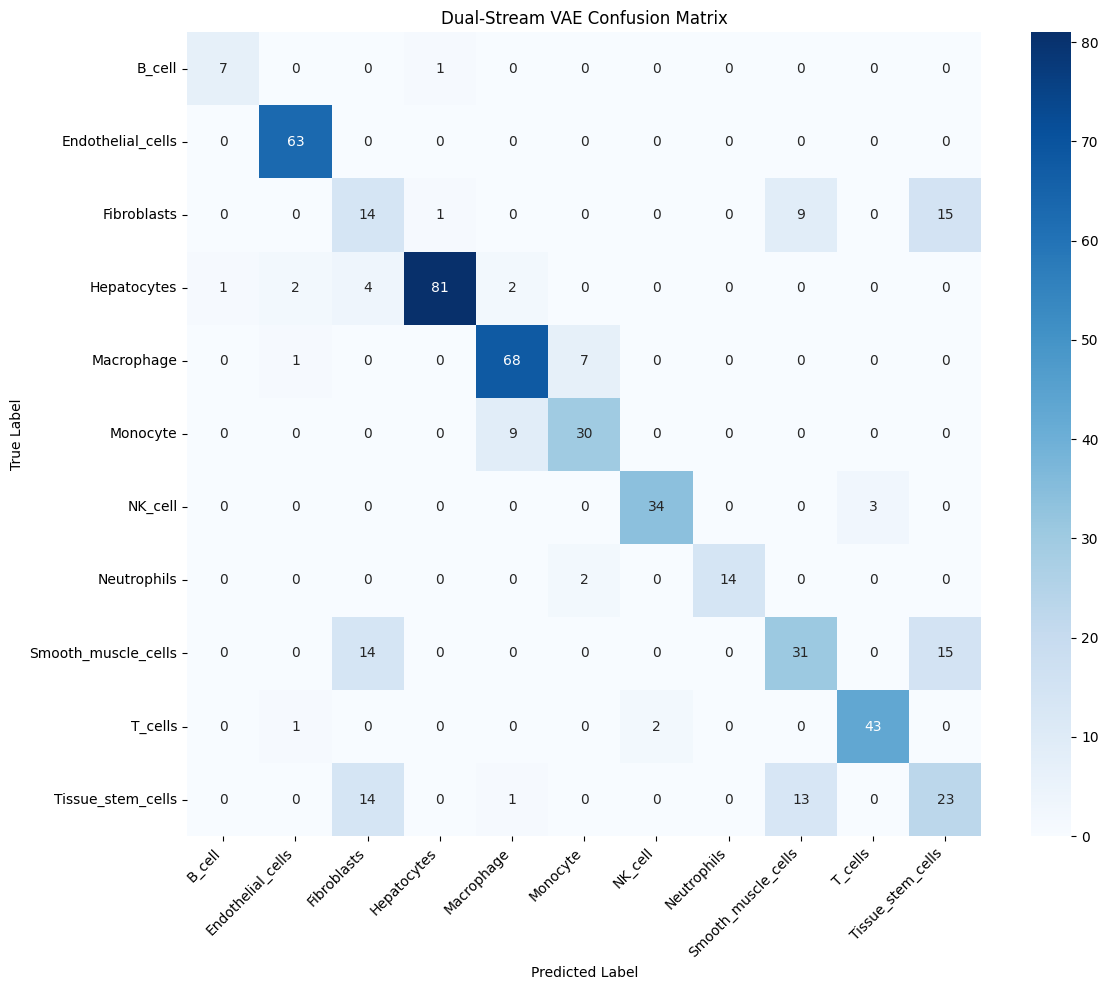


🌌 3. Latent Space 시각화 (Dual-Stream Features)


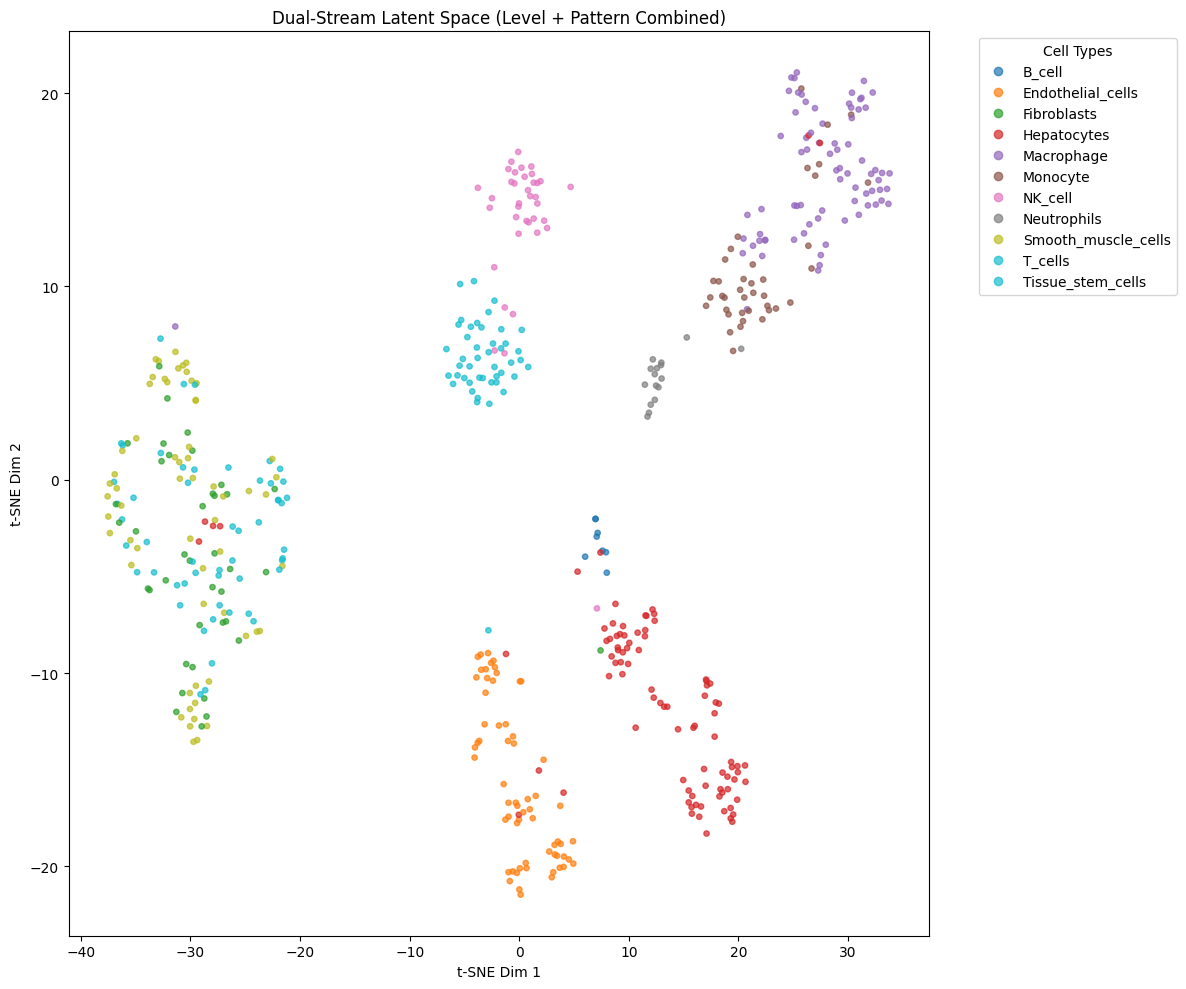

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ======================================================
# 3. 학습 완료 후 최종 시각화 및 평가
# ======================================================

def visualize_results(model, loader, le, device):
    print("\n📊 [최종 평가] 검증 데이터셋 시각화 분석 중...")
    model.eval()

    all_preds = []
    all_targets = []
    all_latents = []

    # 1. 데이터 수집
    with torch.no_grad():
        for bx_lvl, bx_pat, by in loader:
            bx_lvl, bx_pat, by = bx_lvl.to(device), bx_pat.to(device), by.to(device)

            # 모델 추론
            _, logits, mu, _ = model(bx_lvl, bx_pat)
            _, pred = torch.max(logits, 1)

            # 결과 저장
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(by.cpu().numpy())
            all_latents.extend(mu.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_latents = np.array(all_latents)

    # 클래스 정보
    class_names = le.classes_
    class_ids = np.arange(len(class_names))

    # -------------------------------------------------------
    # A. 분류 성능 리포트 (Classification Report)
    # -------------------------------------------------------
    print("\n📝 1. 상세 분류 리포트")
    print("-" * 60)
    print(classification_report(all_targets, all_preds, labels=class_ids, target_names=class_names, zero_division=0))

    # -------------------------------------------------------
    # B. 혼동 행렬 (Confusion Matrix)
    # -------------------------------------------------------
    print("\n🎨 2. 혼동 행렬 (Confusion Matrix)")
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(all_targets, all_preds, labels=class_ids)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Dual-Stream VAE Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------
    # C. Latent Space 시각화 (t-SNE)
    # -------------------------------------------------------
    print("\n🌌 3. Latent Space 시각화 (Dual-Stream Features)")
    # 데이터가 너무 적으면 perplexity 조절
    n_samples = len(all_latents)
    perp = min(30, n_samples - 1) if n_samples > 1 else 1

    try:
        tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
        z_embedded = tsne.fit_transform(all_latents)

        plt.figure(figsize=(12, 10))
        scatter = plt.scatter(z_embedded[:, 0], z_embedded[:, 1],
                              c=all_targets, cmap='tab10', alpha=0.7, s=15)

        # 범례 추가
        handles, _ = scatter.legend_elements()
        plt.legend(handles, class_names, title="Cell Types", bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.title('Dual-Stream Latent Space (Level + Pattern Combined)')
        plt.xlabel('t-SNE Dim 1')
        plt.ylabel('t-SNE Dim 2')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️ t-SNE 시각화 중 오류 발생: {e}")

# --- 실행 명령 ---
# 학습이 끝난 모델(model)과 검증 로더(val_loader)를 사용합니다.
if 'model' in locals() and 'val_loader' in locals():
    visualize_results(model, val_loader, le, device)
else:
    print("⚠️ 모델이나 검증 데이터 로더가 정의되지 않았습니다. 앞의 셀들을 먼저 실행해주세요.")